In [4]:
import os
from typing import List, Literal, TypedDict
from langchain_chroma import Chroma
from langchain_community.document_loaders import (
    DirectoryLoader,
    TextLoader,
)
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph

# ============================================================
# 1. CONFIGURATION
# ============================================================
LMSTUDIO_BASE_URL = os.environ.get(
    "LMSTUDIO_BASE_URL", "http://localhost:1234/v1"
)
DOCS_DIR = "./PDFS"
PERSIST_DIR = "./chroma1_db"
MEMORY_LIMIT = 8
RELEVANCE_THRESHOLD = 1.2

# ============================================================
# 2. LLM
# ============================================================
llm = ChatOpenAI(
    base_url=LMSTUDIO_BASE_URL,
    api_key="lm-studio",
    model="qwen/qwen3-4b-2507",
    temperature=0,
    streaming=True,
)

# ============================================================
# 3. EMBEDDINGS
# ============================================================
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


# ============================================================
# 4. VECTOR DATABASE
# ============================================================
def get_vectorstore() -> Chroma:
    if os.path.exists(PERSIST_DIR):
        return Chroma(
            collection_name="adaptive_rag_docs",
            embedding_function=embeddings,
            persist_directory=PERSIST_DIR,
        )

    if not os.path.exists(DOCS_DIR):
        raise FileNotFoundError(
            f"Directory '{DOCS_DIR}' does not exist. Please create it and add files."
        )

    loader = DirectoryLoader(
        DOCS_DIR,
        glob="**/*.pdf",
        loader_cls=TextLoader,
    )

    documents = loader.load()

    if not documents:
        raise ValueError(f"No .txt documents found in '{DOCS_DIR}'.")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
    )

    chunks = splitter.split_documents(documents)

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name="adaptive_rag_docs",
        persist_directory=PERSIST_DIR,
    )

    return vectorstore


vectorstore = get_vectorstore()

# ============================================================
# 5. WEB SEARCH
# ============================================================
web_search_tool = DuckDuckGoSearchRun()

# ============================================================
# 6. CONVERSATION MEMORY
# ============================================================
conversation_memory: List[BaseMessage] = []


def get_recent_memory() -> List[BaseMessage]:
    return conversation_memory[-MEMORY_LIMIT:]


def save_memory(question: str, answer: str):
    conversation_memory.append(HumanMessage(content=question))
    conversation_memory.append(AIMessage(content=answer))

    if len(conversation_memory) > MEMORY_LIMIT:
        del conversation_memory[:-MEMORY_LIMIT]


# ============================================================
# 7. GRAPH STATE
# ============================================================
class GraphState(TypedDict, total=False):
    question: str
    memory: List[BaseMessage]
    route: Literal["vectorstore", "web_search", "direct"]
    documents: List[Document]
    generation: str


# ============================================================
# 8. NODES
# ============================================================
def load_memory(state: GraphState):
    return {"memory": get_recent_memory()}


def fast_router(state: GraphState):
    question = state["question"].lower()

    web_keywords = [
        "latest",
        "today",
        "current",
        "news",
        "weather",
        "price",
        "stock",
        "recent",
        "live",
    ]

    if any(keyword in question for keyword in web_keywords):
        return {"route": "web_search"}

    local_keywords = ["langgraph","rag","retrieval","vector database","embedding","adaptive rag","games","ai","health","python"]

    if any(keyword in question for keyword in local_keywords):
        return {"route": "vectorstore"}

    return {"route": "direct"}


def retrieve(state: GraphState):
    results = vectorstore.similarity_search_with_score(
        state["question"],
        k=3,
    )

    relevant_documents = [
        doc for doc, score in results if score < RELEVANCE_THRESHOLD
    ]

    return {"documents": relevant_documents}


def decide_after_retrieval(state: GraphState):
    documents = state.get("documents", [])
    if documents:
        return "generate"
    return "direct_answer"


def web_search(state: GraphState):
    results = web_search_tool.invoke(state["question"])
    document = Document(
        page_content=results,
        metadata={"source": "web"},
    )
    return {"documents": [document]}


def generate(state: GraphState):
    context = "\n\n".join(
        doc.page_content for doc in state.get("documents", [])
    )

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful assistant.\n"
                "Use the provided context to answer when the context is relevant.\n"
                "Use conversation history to understand references such as 'that', 'it', or 'explain again'.\n"
                "If the answer is not present in the context, say that clearly instead of inventing information.\n"
                "Keep answers clear and concise.",
            ),
            MessagesPlaceholder(variable_name="memory"),
            (
                "human",
                "CONTEXT:\n{context}\n\nQUESTION:\n{question}",
            ),
        ]
    )

    chain = prompt | llm

    response = chain.invoke(
        {
            "memory": state.get("memory", []),
            "context": context,
            "question": state["question"],
        }
    )

    return {"generation": response.content}


def direct_answer(state: GraphState):
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful assistant.\n"
                "Use the conversation history to understand the user's question.\n"
                "Answer directly and clearly.\n"
                "Do not claim to have searched documents or the web unless such context was provided.",
            ),
            MessagesPlaceholder(variable_name="memory"),
            ("human", "{question}"),
        ]
    )

    chain = prompt | llm

    response = chain.invoke(
        {
            "memory": state.get("memory", []),
            "question": state["question"],
        }
    )

    return {"generation": response.content}


def update_memory(state: GraphState):
    if "generation" in state and state["generation"]:
        save_memory(
            question=state["question"],
            answer=state["generation"],
        )
    return {}


# ============================================================
# 9. BUILD GRAPH
# ============================================================
workflow = StateGraph(GraphState)

workflow.add_node("load_memory", load_memory)
workflow.add_node("fast_router", fast_router)
workflow.add_node("retrieve", retrieve)
workflow.add_node("web_search", web_search)
workflow.add_node("generate", generate)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("update_memory", update_memory)

workflow.add_edge(START, "load_memory")
workflow.add_edge("load_memory", "fast_router")

workflow.add_conditional_edges(
    "fast_router",
    lambda state: state["route"],
    {
        "vectorstore": "retrieve",
        "web_search": "web_search",
        "direct": "direct_answer",
    },
)

workflow.add_conditional_edges(
    "retrieve",
    decide_after_retrieval,
    {
        "generate": "generate",
        "direct_answer": "direct_answer",
    },
)

workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", "update_memory")
workflow.add_edge("direct_answer", "update_memory")
workflow.add_edge("update_memory", END)

app = workflow.compile()

# ============================================================
# 10. CLI
# ============================================================
if __name__ == "__main__":
    print("\nAdaptive RAG Ready!")
    print("Type 'exit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in ["exit", "quit"]:
            break

        if not user_input:
            continue

        print("\nYOU: ",user_input)
        print("\nBot: ", end="", flush=True)

        for message, metadata in app.stream(
            {"question": user_input},
            stream_mode="messages",
        ):
            node = metadata.get("langgraph_node")
            if node in ["generate", "direct_answer"]:
                if message.content:
                    print(
                        message.content,
                        end="",
                        flush=True,
                    )

        print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Adaptive RAG Ready!
Type 'exit' to stop.

YOU:  Hii my name is Niko , i love playing chess

Bot: Hi Niko! That's awesome — chess is such a great game! How do you like to play? Do you prefer classical, blitz, or something else? 😊♟️

YOU:  who am i and what i like

Bot: You're Niko, and you love playing chess! 🎯♟️ That's a great passion — it shows you enjoy strategy, thinking, and a challenge. Keep playing, and maybe one day you'll face a grandmaster or even win a tournament! 😄

YOU:  whats the weather in mumbai

Bot: The current weather in Mumbai is 28°C with a feels-like temperature of 31°C. The forecast shows a high of 29°C and a low of 27°C today, with a chance of rain showers. Sunrise is at 06:22 AM and sunset at 06:56 PM.

YOU:  how ai is used in games , give 5 points

Bot: Sure! Here are 5 key ways AI is used in games:

1. **Enemy Behavior and AI Opponents** – AI controls non-player characters (NPCs) to make them act realistically, such as reacting to player moves, using strategi

In [1]:
import torch

print("PyTorch version:", torch.__version__)

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Create two tensors
a = torch.tensor([1.0, 2.0, 3.0]).to(device)
b = torch.tensor([4.0, 5.0, 6.0]).to(device)

# Simple operation
c = a + b

print("Tensor A:", a)
print("Tensor B:", b)
print("A + B:", c)

# CUDA information
print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nPyTorch is working successfully!")

PyTorch version: 2.11.0+cu128
Using device: cuda
Tensor A: tensor([1., 2., 3.], device='cuda:0')
Tensor B: tensor([4., 5., 6.], device='cuda:0')
A + B: tensor([5., 7., 9.], device='cuda:0')

CUDA available: True
GPU: NVIDIA GeForce GTX 1650

PyTorch is working successfully!


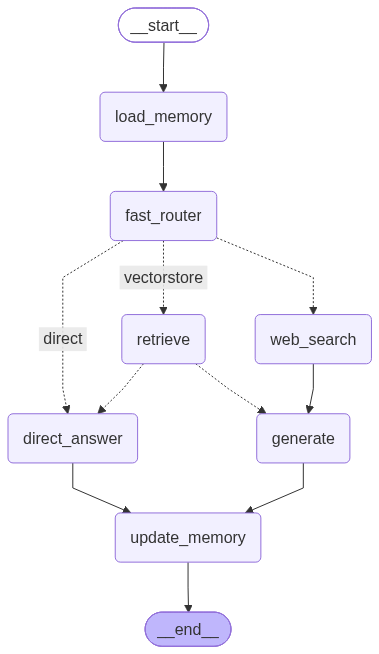

In [4]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))